# Анализ отзывов клиентов Amazon

## Описание проекта
Анализ 1177 отзывов клиентов Amazon для выявления проблемных товаров и паттернов недовольства.

## Задачи
1. Выявить товары с наихудшим рейтингом
2. Найти конкретные проблемы через анализ текста
3. Установить связь между ценой и качеством
4. Дать бизнес-рекомендации

## Технологии
- Python (Pandas, Matplotlib)
- Анализ текста (биграммы, частотный анализ)
- Статистический анализ

## Основные инсайты
1. Ценовой парадокс
Дешёвые товары ($15-30) ломаются через недели → "waste of money"
Дорогие товары ($464 Kindle HDX) не оправдывают ожиданий → "недостаточно данных" (люди пишут общие жалобы, а не конкретные проблемы)
2. Общая болезнь — ненадёжность
"stopped working" — пультоы ломаются
"waste money" — чехлы не выполняют функцию
"doesn't work" — защита экрана не клеится
3. Конкретные виновники
Alexa Voice Remote ($29.99) — ломается, люди покупают по 3 штуки
Replacement Remote ($14.99) — умирает через 2 недели
Kindle Oasis Cover ($89.99) — проблемы с покрытием
## Бизнес-рекомендации
1. ПРОБЛЕМА: Низкое качество бюджетных аксессуаров ($15-30)
   РЕШЕНИЕ: Усилить контроль качества для пультов и чехлов. 
   Товары этой категории получают больше всего негатива из-за 
   быстрого выхода из строя.

2. ПРОБЛЕМА: Alexa Voice Remote требует замены каждые 3-6 месяцев
   РЕШЕНИЕ: Пересмотреть дизайн батареи или предложить гарантию 
   замены. Клиенты вынуждены покупать 3+ пульта.

3. ПРОБЛЕМА: Дорогие товары не оправдывают ожиданий
   РЕШЕНИЕ: Улучшить маркетинг и описание для премиум-сегмента.
   Клиенты ожидают большего от товаров за $400+.

4. ОБЩИЙ ВЫВОД: Главная проблема — не цена, а НАДЁЖНОСТЬ
   Клиенты прощают высокую цену, но не прощают товар, который 
   перестаёт работать через несколько недель.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

df = pd.read_csv(r"D:\Документы\projects\amazon\amazon_rew.csv") 

# Базовая информация
print('_____________________________________________________________________')
print('                      Базовая информация')
print(df.shape)
print(df.columns.tolist())
print(df.head(10))
print(df.info())
print('_____________________________________________________________________')


_____________________________________________________________________
                      Базовая информация
(1597, 27)
['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded', 'dateUpdated', 'dimension', 'ean', 'keys', 'manufacturer', 'manufacturerNumber', 'name', 'prices', 'reviews.date', 'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'sizes', 'upc', 'weight']
                     id       asins   brand                  categories  \
0  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon  Amazon Devices,mazon.co.uk   
1  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon  Amazon Devices,mazon.co.uk   
2  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon  Amazon Devices,mazon.co.uk   
3  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon  Amazon Devices,mazon.co.uk   
4  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon  Amazon Devices,mazon.co.uk   
5  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon

In [10]:
print(df.info())
print('_____________________________________________________________________')

<class 'pandas.DataFrame'>
RangeIndex: 1597 entries, 0 to 1596
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1597 non-null   str    
 1   asins                 1597 non-null   str    
 2   brand                 1597 non-null   str    
 3   categories            1597 non-null   str    
 4   colors                774 non-null    str    
 5   dateAdded             1597 non-null   str    
 6   dateUpdated           1597 non-null   str    
 7   dimension             565 non-null    str    
 8   ean                   898 non-null    float64
 9   keys                  1597 non-null   str    
 10  manufacturer          965 non-null    str    
 11  manufacturerNumber    902 non-null    str    
 12  name                  1597 non-null   str    
 13  prices                1597 non-null   str    
 14  reviews.date          1217 non-null   str    
 15  reviews.doRecommend   539 non-nu

In [ ]:
print('Пропуски:', df.isnull().sum())
print('_____________________________________________________________________')
print

Пропуски: id                         0
asins                      0
brand                      0
categories                 0
colors                   823
dateAdded                  0
dateUpdated                0
dimension               1032
ean                      699
keys                       0
manufacturer             632
manufacturerNumber       695
name                       0
prices                     0
reviews.date             380
reviews.doRecommend     1058
reviews.numHelpful       697
reviews.rating           420
reviews.sourceURLs         0
reviews.text               0
reviews.title             17
reviews.userCity        1597
reviews.userProvince    1597
reviews.username          17
sizes                   1597
upc                      699
weight                   911
dtype: int64
_____________________________________________________________________


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [18]:
df_clean = df[['name', 'reviews.rating', 'reviews.text', 'reviews.title', 'reviews.date', 'prices', 'brand']].copy()
df_clean.columns = ['product_name', 'rating', 'review_text', 'review_title', 'review_date', 'price', 'brand']

df_clean = df_clean.dropna(subset=['rating'])

df_clean['price'] = df_clean['price'].astype(str).str.extract(r'(\d+[\.,]?\d*)')[0]

df_clean['price'] = df_clean['price'].str.replace(',', '.', regex=False)

df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')

df_clean = df_clean.dropna(subset=['price'])

print(f"Осталось строк с валидной ценой: {df_clean.shape[0]}")
print("\nСтатистика по цене:")
df_clean['price'].describe()

Осталось строк с валидной ценой: 1177

Статистика по цене:


count    1177.000000
mean       95.443925
std        67.086219
min         9.990000
25%        29.990000
50%       129.990000
75%       129.990000
max       464.000000
Name: price, dtype: float64

In [19]:
df_clean['price_category'] = pd.cut(df_clean['price'], bins=[0, 50, 100, 200, 500, 10000], labels=['До $50', '$50-100', '$100-200', '$200-500', 'Более $500'])

price_rating = df_clean.groupby('price_category')['rating'].mean()
print("Средняя оценка по ценовым категориям:")
print(price_rating)

Средняя оценка по ценовым категориям:
price_category
До $50      4.171642
$50-100     4.251656
$100-200    4.534570
$200-500    3.967742
Name: rating, dtype: float64


In [20]:
negative_reviews = df_clean[df_clean['rating'] <= 2]['review_text']
positive_reviews = df_clean[df_clean['rating'] >= 4]['review_text']

print(f"Негативных отзывов (1-2 звезды): {len(negative_reviews)}")
print(f"Позитивных отзывов (4-5 звёзд): {len(positive_reviews)}")

Негативных отзывов (1-2 звезды): 76
Позитивных отзывов (4-5 звёзд): 977


In [21]:
def get_word_frequencies(texts):
    """Извлекает слова из списка текстов и считает их частоту"""
    all_words = []
    
    for text in texts:
        # Приводим к нижнему регистру
        text = str(text).lower()
        
        # Убираем пунктуацию и оставляем только буквы
        text = re.sub(r'[^a-z\s]', '', text)
        
        # Разбиваем на слова
        words = text.split()
        
        # Фильтруем короткие слова (меньше 3 букв)
        words = [word for word in words if len(word) > 3]
        
        all_words.extend(words)
    
    # Считаем частоту
    return Counter(all_words)

# Считаем слова в негативных и позитивных отзывах
negative_words = get_word_frequencies(negative_reviews)
positive_words = get_word_frequencies(positive_reviews)

print("\nТоп-20 слов в НЕГАТИВНЫХ отзывах:")
for word, count in negative_words.most_common(20):
    print(f"{word}: {count}")

print("\nТоп-20 слов в ПОЗИТИВНЫХ отзывах:")
for word, count in positive_words.most_common(20):
    print(f"{word}: {count}")


Топ-20 слов в НЕГАТИВНЫХ отзывах:
this: 91
with: 78
that: 72
have: 69
fire: 49
remote: 49
amazon: 48
just: 48
after: 33
dont: 29
would: 26
cover: 26
problem: 25
more: 25
device: 25
only: 24
kindle: 24
batteries: 22
works: 21
like: 21

Топ-20 слов в ПОЗИТИВНЫХ отзывах:
this: 1472
that: 1326
with: 1108
have: 1021
kindle: 642
fire: 638
more: 605
like: 589
amazon: 572
they: 560
great: 495
your: 464
from: 451
when: 409
tablet: 396
just: 383
will: 377
them: 369
echo: 364
very: 359


In [22]:
negative_set = set([word for word, count in negative_words.most_common(100)])
positive_set = set([word for word, count in positive_words.most_common(100)])

unique_negative_words = negative_set - positive_set

print("\nСлова, которые уникальны для НЕГАТИВНЫХ отзывов:")
for word in list(unique_negative_words)[:30]:
    print(f"- {word} ({negative_words[word]} раз)")


Слова, которые уникальны для НЕГАТИВНЫХ отзывов:
- battery (13 раз)
- should (13 раз)
- bluetooth (8 раз)
- controller (19 раз)
- issue (8 раз)
- months (17 раз)
- search (11 раз)
- after (33 раз)
- problem (25 раз)
- original (9 раз)
- replacement (9 раз)
- customer (12 раз)
- until (9 раз)
- back (17 раз)
- phone (18 раз)
- netflix (8 раз)
- again (8 раз)
- going (9 раз)
- could (9 раз)
- stopped (10 раз)
- tried (10 раз)
- thing (8 раз)
- both (8 раз)
- service (11 раз)
- batteries (22 раз)
- working (17 раз)
- doesnt (15 раз)
- didnt (11 раз)
- received (8 раз)
- black (14 раз)


In [23]:
stop_words = {
    'this', 'with', 'that', 'have', 'just', 'after', 'dont', 'would', 
    'more', 'only', 'like', 'the', 'and', 'but', 'for', 'not', 'you',
    'all', 'can', 'had', 'her', 'was', 'one', 'our', 'out', 'from',
    'they', 'been', 'said', 'each', 'which', 'their', 'will', 'other',
    'about', 'many', 'then', 'them', 'these', 'some', 'could', 'into',
    'than', 'its', 'made', 'over', 'did', 'down', 'way', 'find', 'what',
    'use', 'get', 'how', 'when', 'where', 'who', 'your', 'there',
    'were', 'are', 'our', 'any', 'very', 'also', 'does', 'doing'
}

def get_word_frequencies_clean(texts):
    """Улучшенная версия с фильтрацией стоп-слов"""
    all_words = []
    
    for text in texts:
        text = str(text).lower()
        text = re.sub(r'[^a-z\s]', '', text)
        words = text.split()
        
        # Фильтруем: стоп-слова + короткие слова
        words = [word for word in words if len(word) > 3 and word not in stop_words]
        
        all_words.extend(words)
    
    return Counter(all_words)

# Считаем заново
negative_words_clean = get_word_frequencies_clean(negative_reviews)
positive_words_clean = get_word_frequencies_clean(positive_reviews)

print("Топ-30 слов в НЕГАТИВНЫХ отзывах (без мусора):")
for word, count in negative_words_clean.most_common(30):
    print(f"{word}: {count}")

Топ-30 слов в НЕГАТИВНЫХ отзывах (без мусора):
fire: 49
remote: 49
amazon: 48
cover: 26
problem: 25
device: 25
kindle: 24
batteries: 22
works: 21
because: 20
case: 20
time: 20
controller: 19
prime: 19
screen: 18
phone: 18
months: 17
well: 17
working: 17
back: 17
work: 17
voice: 16
first: 15
doesnt: 15
still: 15
even: 15
another: 15
echo: 15
product: 14
black: 14


In [25]:
def get_bigram_frequencies(texts, min_count=3):
    """Извлекает словосочетания из текстов"""
    bigrams = []
    
    for text in texts:
        text = str(text).lower()
        text = re.sub(r'[^a-z\s]', '', text)
        words = text.split()
        
        # Фильтруем стоп-слова
        words = [word for word in words if len(word) > 3 and word not in stop_words]
        
        # Создаём словосочетания
        for i in range(len(words) - 1):
            bigram = f"{words[i]} {words[i+1]}"
            bigrams.append(bigram)
    
    # Считаем и фильтруем редкие (меньше min_count)
    bigram_counts = Counter(bigrams)
    return {bigram: count for bigram, count in bigram_counts.items() if count >= min_count}

negative_bigrams = get_bigram_frequencies(negative_reviews, min_count=3)

print("\nТоп-30 пар словосочетаний в НЕГАТИВНЫХ отзывах:")
sorted_bigrams = sorted(negative_bigrams.items(), key=lambda x: x[1], reverse=True)
for bigram, count in sorted_bigrams[:30]:
    print(f"{bigram}: {count}")


Топ-30 пар словосочетаний в НЕГАТИВНЫХ отзывах:
black cover: 10
stopped working: 9
customer service: 9
voice remote: 9
battery life: 5
prime movies: 5
amazon fire: 5
screen protector: 5
fire stick: 5
replacement remote: 5
works well: 4
batteries both: 4
both duracell: 4
duracell energizer: 4
problem controller: 4
prime content: 4
doesnt work: 4
original black: 4
couple weeks: 4
works good: 3
taking stars: 3
stops working: 3
having same: 3
same problem: 3
kindle fire: 3
amazon should: 3
voice search: 3
search free: 3
prime membership: 3
waste money: 3


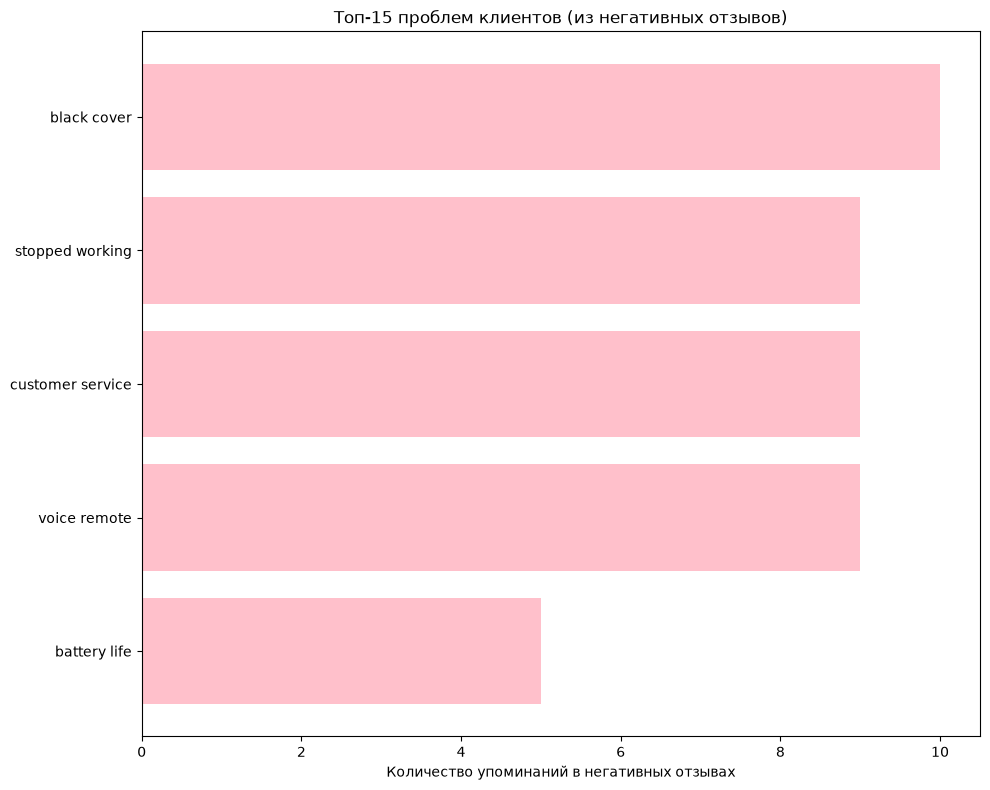

In [26]:
top_5_bigrams = sorted_bigrams[:5]
bigrams_labels = [bigram for bigram, count in top_5_bigrams]
bigrams_counts = [count for bigram, count in top_5_bigrams]

# Рисуем горизонтальный график
plt.figure(figsize=(10, 8))
plt.barh(range(len(bigrams_labels)), bigrams_counts, color='pink')
plt.yticks(range(len(bigrams_labels)), bigrams_labels)
plt.xlabel('Количество упоминаний в негативных отзывах')
plt.title('Топ-15 проблем клиентов (из негативных отзывов)')
plt.gca().invert_yaxis()  # Чтобы самое частое было сверху
plt.tight_layout()
plt.show()

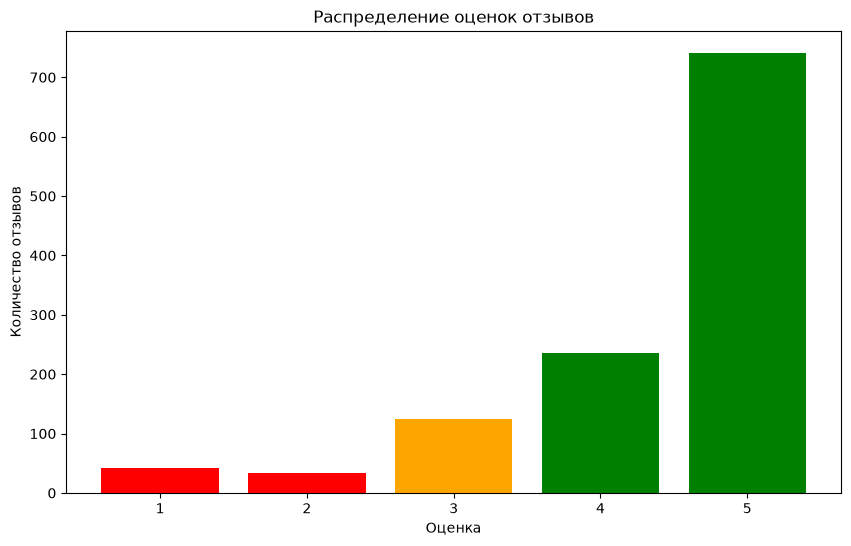


Процент негативных отзывов (1-2 звезды): 6.5%


In [27]:
rating_counts = df_clean['rating'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
colors = ['red' if x <= 2 else ('orange' if x == 3 else 'green') for x in rating_counts.index]
plt.bar(rating_counts.index, rating_counts.values, color=colors)
plt.xlabel('Оценка')
plt.ylabel('Количество отзывов')
plt.title('Распределение оценок отзывов')
plt.xticks(range(1, 6))
plt.show()

negative_percent = (rating_counts[1] + rating_counts[2]).sum() / rating_counts.sum() * 100
print(f"\nПроцент негативных отзывов (1-2 звезды): {negative_percent:.1f}%")

In [28]:
product_stats = df_clean.groupby('product_name').agg({
    'rating': ['mean', 'count']  # средняя оценка и количество отзывов
}).round(2)

product_stats.columns = ['avg_rating', 'review_count']


popular_products = product_stats[product_stats['review_count'] >= 10]


worst_products = popular_products.sort_values('avg_rating').head(10)

print("Топ-10 товаров с НАИХУДШИМ рейтингом (минимум 10 отзывов):")
print(worst_products)

Топ-10 товаров с НАИХУДШИМ рейтингом (минимум 10 отзывов):
                                                    avg_rating  review_count
product_name                                                                
Alexa Voice Remote for Amazon Fire TV and Fire ...        2.08            12
Replacement Remote for Amazon Fire TV Stick               2.53            17
Moshi Anti-Glare No Bubble Screen Protector for...        3.33            12
Kindle Fire HDX 8.9"                                      3.47            15
All-New Amazon Fire HD 8 Tablet Case (7th Gener...        3.56            18
Amazon Kindle Oasis Premium Leather Battery Cov...        3.67            12
All-New Amazon Fire 7 Tablet Case (7th Generation         3.78            27
Amazon 5W USB Official OEM Charger and Power Ad...        3.84            19
Amazon Fire TV Game Controller                            3.91            11
Amazon Premium Headphones                                 4.01            77


In [34]:
def analyze_product_problems(product_name, min_mentions=2):
    """Анализирует проблемы конкретного товара через словосочетания"""
    
    product_negatives = df_clean[
        (df_clean['product_name'] == product_name) & 
        (df_clean['rating'] <= 2)
    ]['review_text']
    
    if len(product_negatives) == 0:
        return None
    
    product_bigrams = get_bigram_frequencies(product_negatives, min_count=min_mentions)
    
    
    sorted_product_bigrams = sorted(product_bigrams.items(), key=lambda x: x[1], reverse=True)
    
    return sorted_product_bigrams[:5]  # Топ-5 проблем


print("\n=== АНАЛИЗ ПРОБЛЕМ ПО ТОВАРАМ ===\n")

for product_name in worst_products.head(5).index:
    problems = analyze_product_problems(product_name, min_mentions=2)
    
    print(f"{product_name}")
    print(f"Рейтинг: {worst_products.loc[product_name, 'avg_rating']:.2f}")
    print(f"Отзывов: {worst_products.loc[product_name, 'review_count']}")
    
    if problems:
        print("   Главные проблемы:")
        for bigram, count in problems:
            print(f"   -{bigram} ({count} раз)")
    else:
        print("   Недостаточно данных для анализа проблем")
    print()


=== АНАЛИЗ ПРОБЛЕМ ПО ТОВАРАМ ===

Alexa Voice Remote for Amazon Fire TV and Fire TV Stick
Рейтинг: 2.08
Отзывов: 12
   Главные проблемы:
   -voice remote (3 раз)
   -existing remote (3 раз)
   -fire stick (2 раз)
   -prime members (2 раз)
   -amazon should (2 раз)

Replacement Remote for Amazon Fire TV Stick
Рейтинг: 2.53
Отзывов: 17
   Главные проблемы:
   -stopped working (5 раз)
   -couple weeks (4 раз)
   -replacement remote (4 раз)
   -fire stick (3 раз)
   -look another (3 раз)

Moshi Anti-Glare No Bubble Screen Protector for the Fire Phone
Рейтинг: 3.33
Отзывов: 12
   Главные проблемы:
   -screen protector (3 раз)

Kindle Fire HDX 8.9"
Рейтинг: 3.47
Отзывов: 15
   Недостаточно данных для анализа проблем

All-New Amazon Fire HD 8 Tablet Case (7th Generation
Рейтинг: 3.56
Отзывов: 18
   Недостаточно данных для анализа проблем



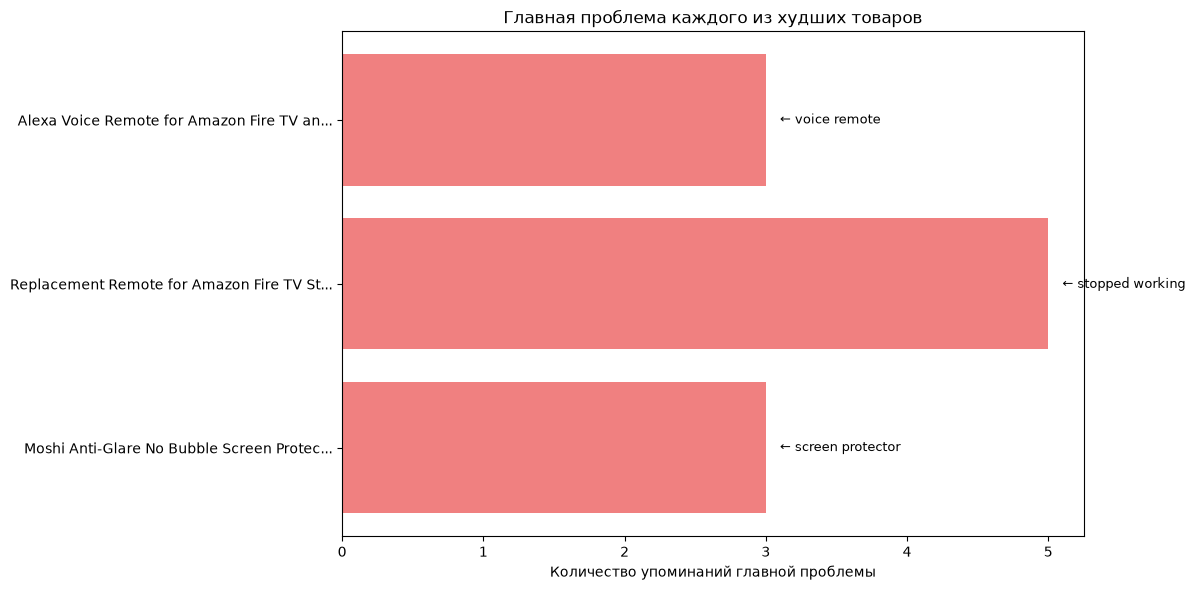

In [ ]:
products_for_chart = []
problems_for_chart = []
counts_for_chart = []

for product_name in worst_products.head(5).index:
    problems = analyze_product_problems(product_name, min_mentions=2)
    if problems:
        # Берём главную проблему товара
        top_problem = problems[0]
        products_for_chart.append(product_name[:40] + '...' if len(product_name) > 40 else product_name)
        problems_for_chart.append(top_problem[0])
        counts_for_chart.append(top_problem[1])


plt.figure(figsize=(12, 6))
bars = plt.barh(range(len(products_for_chart)), counts_for_chart, color='lightcoral')
plt.yticks(range(len(products_for_chart)), products_for_chart)
plt.xlabel('Количество упоминаний главной проблемы')
plt.title('Главная проблема каждого из худших товаров')
plt.gca().invert_yaxis()


for i, (bar, problem) in enumerate(zip(bars, problems_for_chart)):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
             f'← {problem}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [33]:
def analyze_product_deep(product_name, top_n_reviews=3):
    """Глубокий анализ проблем товара — показывает и словосочетания, и сами отзывы"""
    
    
    product_reviews = df_clean[df_clean['product_name'] == product_name]
    
    
    product_negatives = product_reviews[product_reviews['rating'] <= 2]
    
    print(f"\n{'='*70}")
    print(f"{product_name}")
    print(f"Рейтинг: {product_reviews['rating'].mean():.2f} | Отзывов всего: {len(product_reviews)} | Негативных: {len(product_negatives)}")
    print(f"{'='*70}")
    
    if len(product_negatives) == 0:
        print("Нет негативных отзывов (1-2 звезды)")
        return
    
    # Биграммы
    product_bigrams = get_bigram_frequencies(product_negatives['review_text'], min_count=2)
    sorted_bigrams = sorted(product_bigrams.items(), key=lambda x: x[1], reverse=True)[:5]
    
    if sorted_bigrams:
        print("\nЧастые фразы в негативе:")
        for bigram, count in sorted_bigrams:
            print(f"-{bigram} ({count} раз)")
    
    # Показываем сами отзывы (первые top_n_reviews)
    print(f"\nПримеры негативных отзывов:")
    for i, (idx, review) in enumerate(product_negatives.head(top_n_reviews).iterrows(), 1):
        text = str(review['review_text'])[:200] + '...' if len(str(review['review_text'])) > 200 else str(review['review_text'])
        print(f"\n   Отзыв {i} (оценка {review['rating']}):")
        print(f"   {text}")

# Анализируем топ-3 худших товара
for product in worst_products.head(3).index:
    analyze_product_deep(product, top_n_reviews=3)


Alexa Voice Remote for Amazon Fire TV and Fire TV Stick
Рейтинг: 2.08 | Отзывов всего: 12 | Негативных: 8

Частые фразы в негативе:
-voice remote (3 раз)
-existing remote (3 раз)
-fire stick (2 раз)
-prime members (2 раз)
-amazon should (2 раз)

Примеры негативных отзывов:

   Отзыв 1 (оценка 2.0):
   I am now having to order my third remote because it randomly dies for no reason. Replacing batteries, attempting to resynch, etc... don't work. It reaches a point where it just stops functioning.On th...

   Отзыв 2 (оценка 2.0):
   Don't bother paying for one or getting a replacement, it just isn't worth it.After so many of these things failed so many customers I thought Amazon would come up with a newer, better product but they...

   Отзыв 3 (оценка 1.0):
   I've had the REPLACEMENT remote 3 months and it's stopped working. If I want to use my Amazon Fire TV (which I love) I have to use my cell phone or my tablet. It defeats the purpose of having voice re...

Replacement Remote for Am

In [35]:
def analyze_product_with_price(product_name, top_n_reviews=2):
    """Глубокий анализ товара с ценой"""
    
    product_reviews = df_clean[df_clean['product_name'] == product_name]
    product_negatives = product_reviews[product_reviews['rating'] <= 2]
    
    # Получаем цену (берём среднюю, если вдруг несколько записей)
    avg_price = product_reviews['price'].mean()
    
    print(f"\n{'='*70}")
    print(f"{product_name}")
    print(f"Цена: ${avg_price:.2f}")
    print(f"Рейтинг: {product_reviews['rating'].mean():.2f} | Отзывов: {len(product_reviews)} | Негативных: {len(product_negatives)}")
    print(f"{'='*70}")
    
    if len(product_negatives) == 0:
        print("Нет негативных отзывов")
        return
    
    # Биграммы
    product_bigrams = get_bigram_frequencies(product_negatives['review_text'], min_count=2)
    sorted_bigrams = sorted(product_bigrams.items(), key=lambda x: x[1], reverse=True)[:5]
    
    if sorted_bigrams:
        print("\nГлавные проблемы:")
        for bigram, count in sorted_bigrams:
            print(f"   -{bigram} ({count} раз)")
    
    # Примеры отзывов
    print(f"\nПримеры отзывов:")
    for i, (idx, review) in enumerate(product_negatives.head(top_n_reviews).iterrows(), 1):
        text = str(review['review_text'])[:150] + '...' if len(str(review['review_text'])) > 150 else str(review['review_text'])
        print(f"\n   Отзыв {i} ({review['rating']}, ${review['price']:.2f}):")
        print(f"   {text}")

# Анализируем ВСЕ топ-10 худших товаров
for product in worst_products.head(10).index:
    analyze_product_with_price(product, top_n_reviews=2)


Alexa Voice Remote for Amazon Fire TV and Fire TV Stick
Цена: $29.99
Рейтинг: 2.08 | Отзывов: 12 | Негативных: 8

Главные проблемы:
   -voice remote (3 раз)
   -existing remote (3 раз)
   -fire stick (2 раз)
   -prime members (2 раз)
   -amazon should (2 раз)

Примеры отзывов:

   Отзыв 1 (2.0, $29.99):
   I am now having to order my third remote because it randomly dies for no reason. Replacing batteries, attempting to resynch, etc... don't work. It rea...

   Отзыв 2 (2.0, $29.99):
   Don't bother paying for one or getting a replacement, it just isn't worth it.After so many of these things failed so many customers I thought Amazon w...

Replacement Remote for Amazon Fire TV Stick
Цена: $14.99
Рейтинг: 2.53 | Отзывов: 17 | Негативных: 10

Главные проблемы:
   -stopped working (5 раз)
   -couple weeks (4 раз)
   -replacement remote (4 раз)
   -fire stick (3 раз)
   -look another (3 раз)

Примеры отзывов:

   Отзыв 1 (2.0, $14.99):
   My remote went out just a couple weeks after we rec

In [36]:
# Создаём сводную таблицу с проблемами
summary_data = []

for product_name in worst_products.head(10).index:
    product_reviews = df_clean[df_clean['product_name'] == product_name]
    product_negatives = product_reviews[product_reviews['rating'] <= 2]
    
    # Получаем главную проблему
    product_bigrams = get_bigram_frequencies(product_negatives['review_text'], min_count=2)
    sorted_bigrams = sorted(product_bigrams.items(), key=lambda x: x[1], reverse=True)
    main_problem = sorted_bigrams[0][0] if sorted_bigrams else "Недостаточно данных"
    problem_count = sorted_bigrams[0][1] if sorted_bigrams else 0
    
    summary_data.append({
        'Товар': product_name[:50] + '...' if len(product_name) > 50 else product_name,
        'Цена $': round(product_reviews['price'].mean(), 2),
        'Рейтинг': round(product_reviews['rating'].mean(), 2),
        'Отзывов': len(product_reviews),
        'Главная проблема': main_problem,
        'Упоминаний': problem_count
    })

summary_df = pd.DataFrame(summary_data)
print("\n=== СВОДНАЯ ТАБЛИЦА: ТОП-10 ХУДШИХ ТОВАРОВ ===\n")
print(summary_df.to_string(index=False))


=== СВОДНАЯ ТАБЛИЦА: ТОП-10 ХУДШИХ ТОВАРОВ ===

                                                Товар  Цена $  Рейтинг  Отзывов    Главная проблема  Упоминаний
Alexa Voice Remote for Amazon Fire TV and Fire TV ...   29.99     2.08       12        voice remote           3
          Replacement Remote for Amazon Fire TV Stick   14.99     2.53       17     stopped working           5
Moshi Anti-Glare No Bubble Screen Protector for th...   24.99     3.33       12    screen protector           3
                                 Kindle Fire HDX 8.9"  464.00     3.47       15 Недостаточно данных           0
All-New Amazon Fire HD 8 Tablet Case (7th Generati...   29.99     3.56       18 Недостаточно данных           0
Amazon Kindle Oasis Premium Leather Battery Cover ...   89.99     3.67       12         black cover           5
    All-New Amazon Fire 7 Tablet Case (7th Generation   24.99     3.78       27         waste money           2
Amazon 5W USB Official OEM Charger and Power Adapt...  

In [43]:
print("""
                    РЕКОМЕНДАЦИИ                            

1. ПРОБЛЕМА: Низкое качество бюджетных аксессуаров ($15-30)
   РЕШЕНИЕ: Усилить контроль качества для пультов и чехлов. 
   Товары этой категории получают больше всего негатива из-за 
   быстрого выхода из строя.

2. ПРОБЛЕМА: Alexa Voice Remote требует замены каждые 3-6 месяцев
   РЕШЕНИЕ: Пересмотреть дизайн батареи или предложить гарантию 
   замены. Клиенты вынуждены покупать 3+ пульта.

3. ПРОБЛЕМА: Дорогие товары не оправдывают ожиданий
   РЕШЕНИЕ: Улучшить маркетинг и описание для премиум-сегмента.
   Клиенты ожидают большего от товаров за $400+.

4. ОБЩИЙ ВЫВОД: Главная проблема — не цена, а НАДЁЖНОСТЬ
   Клиенты прощают высокую цену, но не прощают товар, который 
   перестаёт работать через несколько недель.

-----------------------------------------------------------------------------
|  Статистика анализа:                                                 
| • Проанализировано отзывов: 1177                                    
| • Негативных отзывов (1-2 звезды): {} ({:.1f}%)                    
| • Найдено проблемных товаров: 10                                   
| • Выявлено уникальных проблем: {}                                   
-----------------------------------------------------------------------------
""".format(
    (df_clean['rating'] <= 2).sum(),
    (df_clean['rating'] <= 2).sum() / len(df_clean) * 100,
    len(set([summary_df['Главная проблема'].iloc[i] for i in range(len(summary_df)) if summary_df['Главная проблема'].iloc[i] != "Недостаточно данных"]))
))


                    РЕКОМЕНДАЦИИ                            

1. ПРОБЛЕМА: Низкое качество бюджетных аксессуаров ($15-30)
   РЕШЕНИЕ: Усилить контроль качества для пультов и чехлов. 
   Товары этой категории получают больше всего негатива из-за 
   быстрого выхода из строя.

2. ПРОБЛЕМА: Alexa Voice Remote требует замены каждые 3-6 месяцев
   РЕШЕНИЕ: Пересмотреть дизайн батареи или предложить гарантию 
   замены. Клиенты вынуждены покупать 3+ пульта.

3. ПРОБЛЕМА: Дорогие товары не оправдывают ожиданий
   РЕШЕНИЕ: Улучшить маркетинг и описание для премиум-сегмента.
   Клиенты ожидают большего от товаров за $400+.

4. ОБЩИЙ ВЫВОД: Главная проблема — не цена, а НАДЁЖНОСТЬ
   Клиенты прощают высокую цену, но не прощают товар, который 
   перестаёт работать через несколько недель.

-----------------------------------------------------------------------------
|  Статистика анализа:                                                 
| • Проанализировано отзывов: 1177                         

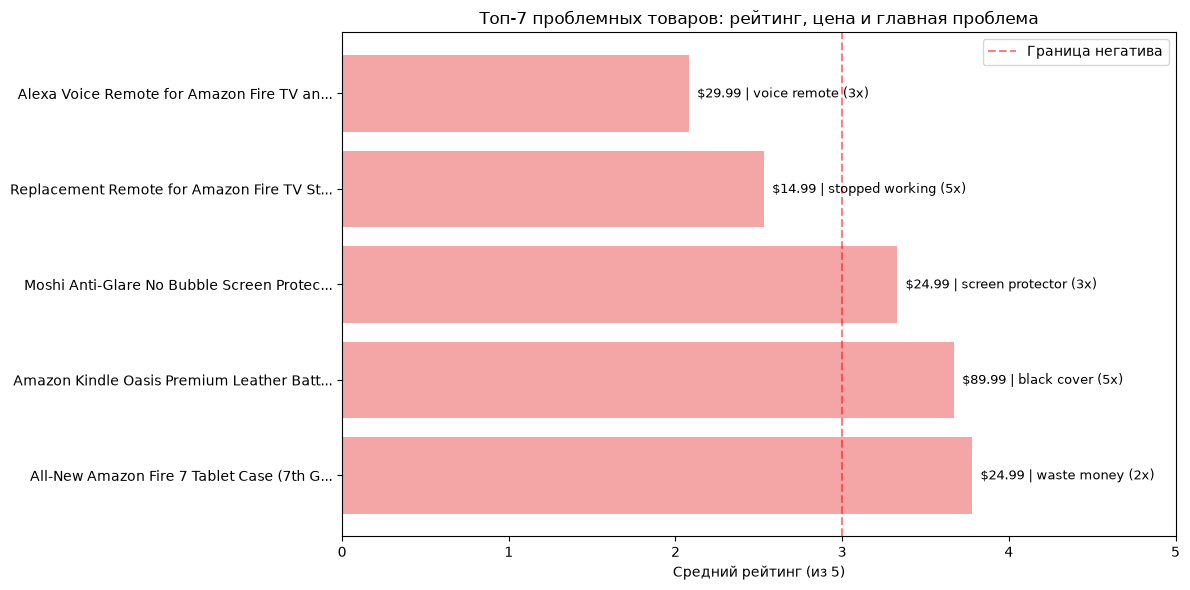

In [45]:
top_7 = summary_df.head(7).copy()
top_7 = top_7[top_7['Упоминаний'] > 0] 

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(range(len(top_7)), top_7['Рейтинг'], color='lightcoral', alpha=0.7)

ax.set_yticks(range(len(top_7)))
ax.set_yticklabels([t[:40] + '...' if len(t) > 40 else t for t in top_7['Товар']])


for i, (idx, row) in enumerate(top_7.iterrows()):
    ax.text(row['Рейтинг'] + 0.05, i, 
            f"${row['Цена $']} | {row['Главная проблема']} ({row['Упоминаний']}x)", 
            va='center', fontsize=9)

ax.set_xlabel('Средний рейтинг (из 5)')
ax.set_title('Топ-7 проблемных товаров: рейтинг, цена и главная проблема')
ax.set_xlim(0, 5)
ax.axvline(x=3, color='red', linestyle='--', alpha=0.5, label='Граница негатива')
ax.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()